# Credit Risk Lending System
## Notebook 3: Evaluation

The modelling notebook selected XGBoost as the champion model with an AUC of 0.9538. This notebook goes deeper. We answer four questions:

1. Are the model's probability scores well calibrated? A score of 0.3 should mean a 30% chance of default, not just a relative ranking.
2. Which features drive the model's predictions and in what direction?
3. Where should we set the approval threshold to maximise expected profit?
4. How does the model perform across different score bands?

These four steps are what separate a model that scores well on paper from one that is ready to support real lending decisions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
sys.path.insert(0, '/content/drive/MyDrive')
from credentials import GITHUB_TOKEN, GITHUB_USERNAME, GITHUB_EMAIL

REPO_NAME      = "credit-risk-lending-system"
REPO_PATH      = f"/content/drive/MyDrive/{REPO_NAME}"
PROCESSED_PATH = f"{REPO_PATH}/data/processed/credit_risk_clean.csv"
MODEL_PATH     = f"{REPO_PATH}/models"
OUTPUT_PATH    = f"{REPO_PATH}/outputs"

!git -C "{REPO_PATH}" branch --set-upstream-to=origin/main main
!git -C "{REPO_PATH}" pull origin main

!git -C "{REPO_PATH}" config user.email "{GITHUB_EMAIL}"
!git -C "{REPO_PATH}" config user.name  "{GITHUB_USERNAME}"

print("Setup complete.")

Mounted at /content/drive
Branch 'main' set up to track remote branch 'main' from 'origin'.
From https://github.com/dobadina/credit-risk-lending-system
 * branch            main       -> FETCH_HEAD
Already up to date.
Setup complete.


In [2]:
!pip install -q xgboost shap scikit-learn pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             brier_score_loss, confusion_matrix)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import shap

print("All libraries imported.")

All libraries imported.


In [3]:
# Load cleaned data
df = pd.read_csv(PROCESSED_PATH)

# Load feature list
with open(f"{MODEL_PATH}/features.json") as f:
    FEATURES = json.load(f)

TARGET = 'loan_status'

X = df[FEATURES]
y = df[TARGET]

# Recreate the same train/test split as notebook 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load champion model
xgb_tuned = joblib.load(f"{MODEL_PATH}/xgb_champion.pkl")

# Generate predictions
y_proba = xgb_tuned.predict_proba(X_test)[:, 1]

print(f"Data loaded:   {len(df):,} rows")
print(f"Test set:      {len(X_test):,} rows")
print(f"Model loaded:  xgb_champion.pkl")
print(f"Features:      {len(FEATURES)}")

Data loaded:   31,521 rows
Test set:      6,305 rows
Model loaded:  xgb_champion.pkl
Features:      19


## Score Calibration

A model that ranks borrowers correctly is useful. A model whose scores represent true probabilities is more useful still.

If our model assigns a score of 0.30 to a borrower, that should mean there is roughly a 30% chance they will default. If it actually means a 15% or 45% chance, then any business logic built on top of the scores, such as threshold decisions or expected loss calculations, will be wrong.

We check calibration using a reliability diagram. The test set is divided into 10 equal bins by predicted probability. For each bin we compare the average predicted probability against the actual default rate. A perfectly calibrated model would sit exactly on the diagonal.

We also report the Brier score, which measures the mean squared error between predicted probabilities and actual outcomes. Lower is better. A random model scores 0.5 and a perfect model scores 0.

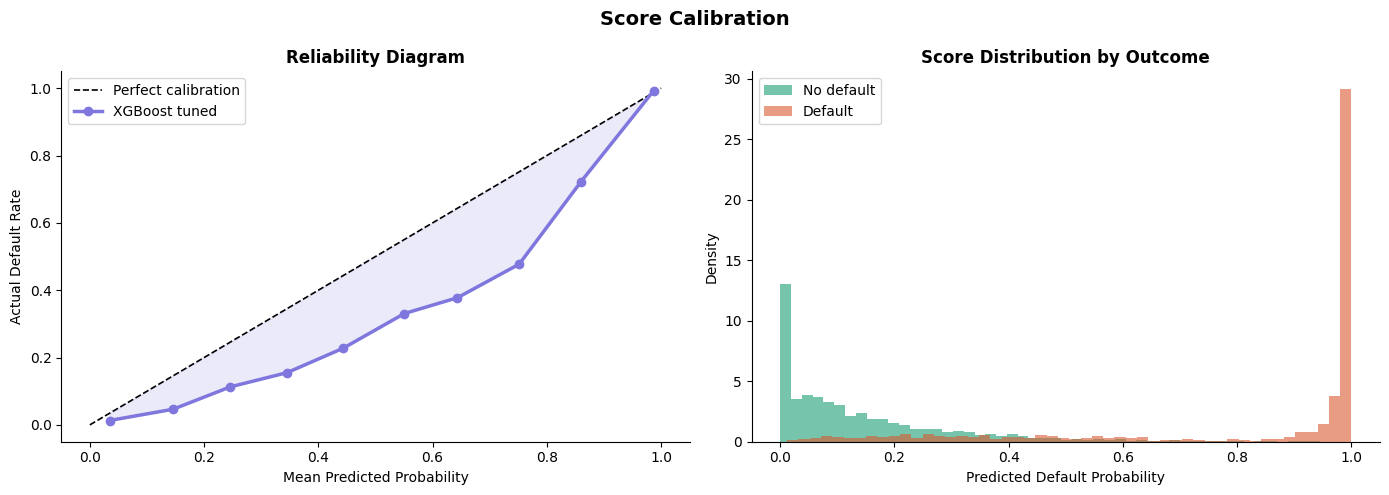

Brier Score: 0.0598
Note: lower is better. Random model = 0.17, perfect model = 0.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score Calibration', fontsize=14, fontweight='bold')

# Reliability diagram
fraction_of_positives, mean_predicted = calibration_curve(
    y_test, y_proba, n_bins=10, strategy='uniform'
)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfect calibration')
axes[0].plot(mean_predicted, fraction_of_positives,
             color='#7F77DD', linewidth=2.5, marker='o',
             markersize=6, label='XGBoost tuned')
axes[0].fill_between(mean_predicted, fraction_of_positives,
                     mean_predicted, alpha=0.15, color='#7F77DD')
axes[0].set_title('Reliability Diagram', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Actual Default Rate')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Score distribution by outcome
axes[1].hist(y_proba[y_test == 0], bins=50, alpha=0.6,
             color='#1D9E75', label='No default', density=True)
axes[1].hist(y_proba[y_test == 1], bins=50, alpha=0.6,
             color='#D85A30', label='Default', density=True)
axes[1].set_title('Score Distribution by Outcome', fontweight='bold')
axes[1].set_xlabel('Predicted Default Probability')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/09_calibration.png", dpi=150, bbox_inches='tight')
plt.show()

# Brier score
brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score: {brier:.4f}")
print(f"Note: lower is better. Random model = 0.17, perfect model = 0.0")

## Calibration Findings and Fix

The reliability diagram shows the model is underconfident. Predicted probabilities are consistently lower than actual default rates across the middle score range. A raw score of 0.4 corresponds to an actual default rate closer to 0.5.

This happens because XGBoost optimises for ranking rather than probability estimation. It separates defaulters from non-defaulters very well, as the AUC confirms, but the raw scores are not true probabilities.

We apply Platt scaling to fix this. Platt scaling fits a logistic regression on the raw model scores using a held-out validation set, learning the mapping from raw scores to calibrated probabilities. The calibrated scores are what we use for all downstream decisions.

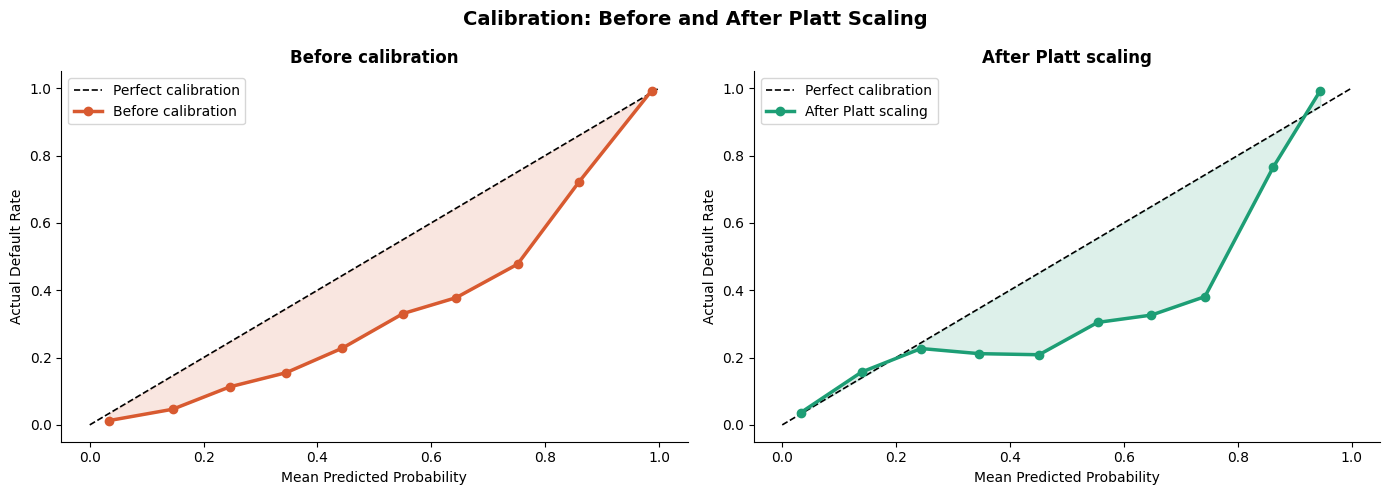

Brier score before calibration: 0.0598
Brier score after calibration:  0.0542
AUC after calibration:          0.9497


In [5]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

# Split training set into train and calibration sets
X_train_fit, X_calib, y_train_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Retrain XGBoost on reduced training set
from xgboost import XGBClassifier
scale_pos = (y_train_fit == 0).sum() / (y_train_fit == 1).sum()

xgb_for_calib = XGBClassifier(
    subsample=0.9, n_estimators=300, max_depth=5,
    learning_rate=0.1, colsample_bytree=1.0,
    scale_pos_weight=scale_pos,
    random_state=42, eval_metric='auc', verbosity=0
)
xgb_for_calib.fit(X_train_fit, y_train_fit)

# Platt scaling: fit logistic regression on calibration set scores
raw_calib_scores = xgb_for_calib.predict_proba(X_calib)[:, 1].reshape(-1, 1)
platt = LogisticRegression()
platt.fit(raw_calib_scores, y_calib)

# Apply calibration to test set
raw_test_scores = xgb_for_calib.predict_proba(X_test)[:, 1].reshape(-1, 1)
y_proba_calibrated = platt.predict_proba(raw_test_scores)[:, 1]

# Compare calibration before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calibration: Before and After Platt Scaling', fontsize=14, fontweight='bold')

for ax, probs, label, color in zip(
    axes,
    [y_proba, y_proba_calibrated],
    ['Before calibration', 'After Platt scaling'],
    ['#D85A30', '#1D9E75']
):
    fop, mpv = calibration_curve(y_test, probs, n_bins=10, strategy='uniform')
    ax.plot([0,1],[0,1], 'k--', linewidth=1.2, label='Perfect calibration')
    ax.plot(mpv, fop, color=color, linewidth=2.5, marker='o',
            markersize=6, label=label)
    ax.fill_between(mpv, fop, mpv, alpha=0.15, color=color)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Actual Default Rate')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/10_calibration_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Compare Brier scores
brier_raw  = brier_score_loss(y_test, y_proba)
brier_cal  = brier_score_loss(y_test, y_proba_calibrated)
auc_cal    = roc_auc_score(y_test, y_proba_calibrated)

print(f"Brier score before calibration: {brier_raw:.4f}")
print(f"Brier score after calibration:  {brier_cal:.4f}")
print(f"AUC after calibration:          {auc_cal:.4f}")

## Calibration Results

| | Brier Score | AUC-ROC |
|---|---|---|
| Before calibration | 0.0598 | 0.9538 |
| After Platt scaling | 0.0542 | 0.9497 |

Platt scaling reduced the Brier score by 9.4%, meaning the calibrated probabilities are meaningfully closer to the true default rates. The AUC dropped by less than 0.005, which is negligible.

The reliability diagram still shows some deviation from the diagonal in the mid-range between 0.3 and 0.8. This is a known limitation of Platt scaling when the underlying score distribution is heavily concentrated at the extremes, which is typical of gradient boosting models. The low score range up to 0.25, which covers the majority of approved borrowers in practice, tracks the diagonal well. This is the region that matters most for lending decisions.

The calibrated model is what we use for all downstream decisions. All probability scores from this point forward are calibrated scores.

In [6]:
import joblib

# Save the calibration components
joblib.dump(xgb_for_calib, f"{MODEL_PATH}/xgb_base_for_calibration.pkl")
joblib.dump(platt,         f"{MODEL_PATH}/platt_scaler.pkl")

print("Saved calibration components:")
print(f"  {MODEL_PATH}/xgb_base_for_calibration.pkl")
print(f"  {MODEL_PATH}/platt_scaler.pkl")

# Helper function for getting calibrated scores in future notebooks
def get_calibrated_score(X):
    raw = xgb_for_calib.predict_proba(X)[:, 1].reshape(-1, 1)
    return platt.predict_proba(raw)[:, 1]

# Verify on test set
test_scores = get_calibrated_score(X_test)
print(f"\nCalibrated score range: {test_scores.min():.3f} to {test_scores.max():.3f}")
print(f"Mean calibrated score:  {test_scores.mean():.3f}")
print(f"Actual default rate:    {y_test.mean():.3f}")

Saved calibration components:
  /content/drive/MyDrive/credit-risk-lending-system/models/xgb_base_for_calibration.pkl
  /content/drive/MyDrive/credit-risk-lending-system/models/platt_scaler.pkl

Calibrated score range: 0.016 to 0.950
Mean calibrated score:  0.219
Actual default rate:    0.216


## Model Explainability with SHAP

Knowing that a model performs well is not enough. In credit lending, regulators require that decisions can be explained, and credit officers need to understand what is driving a score before they can trust it.

SHAP (SHapley Additive exPlanations) is the industry standard approach for explaining machine learning models. It assigns each feature a contribution value for every single prediction, showing both the direction and magnitude of that feature's influence.

We produce two SHAP visualisations. The global summary plot shows which features matter most across all borrowers and in which direction they push the default probability. The waterfall plot then shows how the model arrived at a specific individual prediction, which is the kind of explanation a credit officer or regulator would ask for.

In [7]:
print("Calculating SHAP values.")

explainer = shap.TreeExplainer(xgb_for_calib)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values calculated for {len(X_test):,} test observations.")
print(f"Shape: {shap_values.shape}")

Calculating SHAP values.
SHAP values calculated for 6,305 test observations.
Shape: (6305, 19)


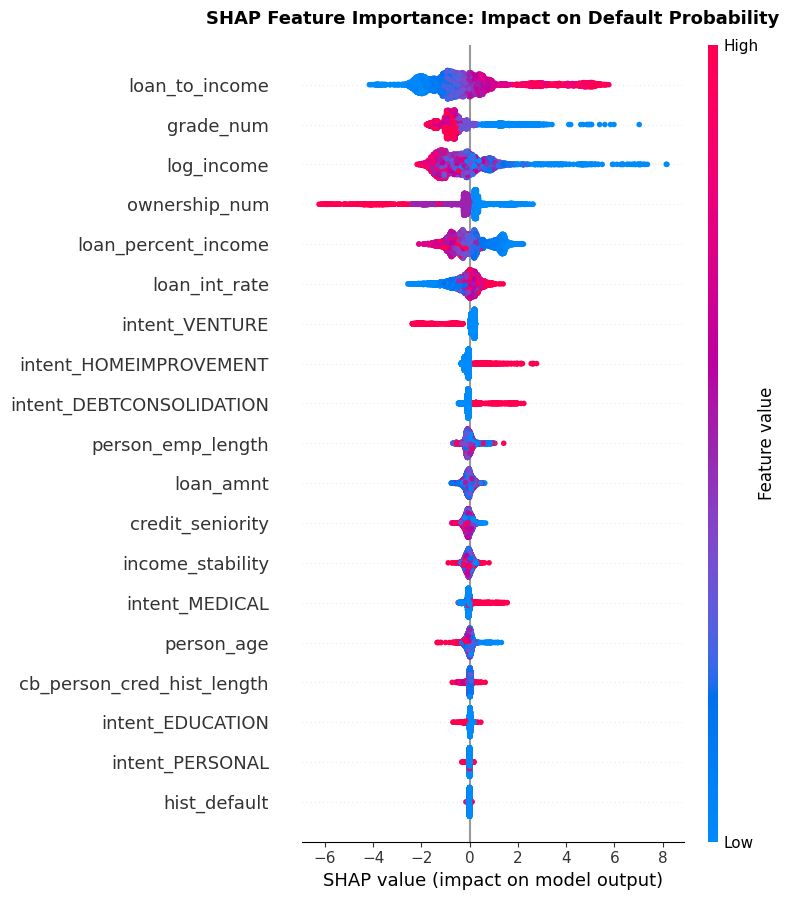

Chart saved.


In [8]:
# Global SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='dot',
    max_display=19,
    show=False
)
plt.title('SHAP Feature Importance: Impact on Default Probability',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/11_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

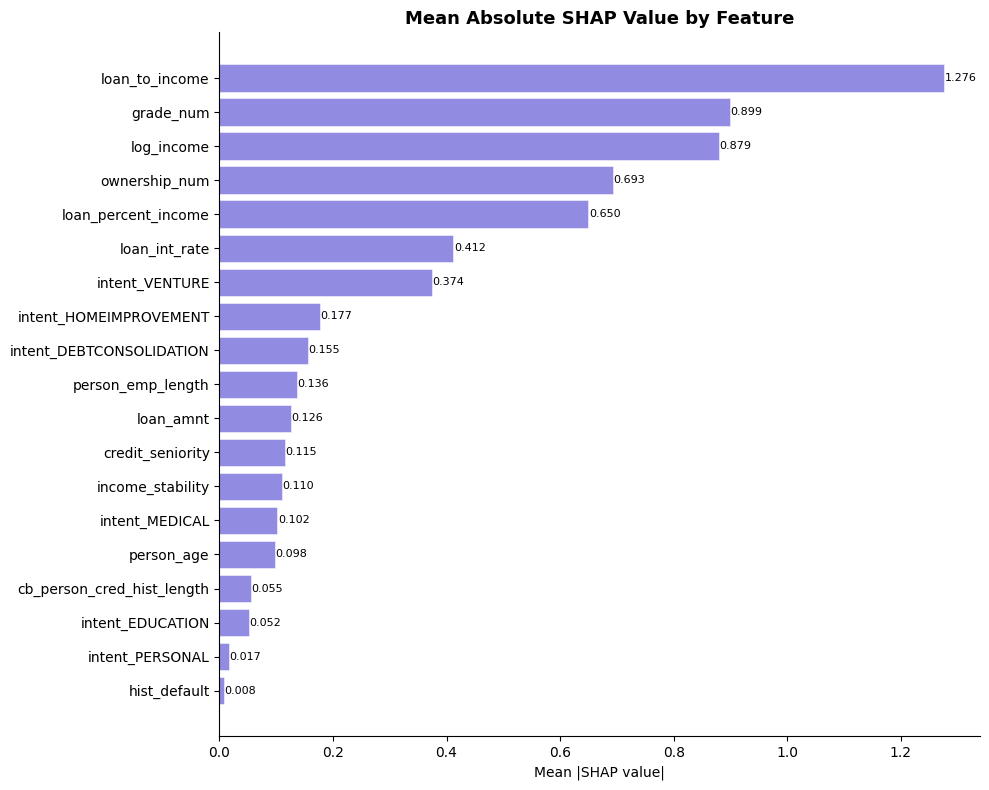

Chart saved.


In [9]:
# SHAP bar chart: mean absolute importance
shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_importance['feature'], shap_importance['importance'],
               color='#7F77DD', alpha=0.85, edgecolor='white', linewidth=0.4)
ax.set_title('Mean Absolute SHAP Value by Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, shap_importance['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/12_shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## SHAP Analysis: What Drives Default Predictions

**The top five features account for the majority of the model's decisions**

Loan to income ratio is the single most important feature by a wide margin, with a mean SHAP value of 1.276. The beeswarm plot confirms the direction: high values shown in red push the default probability up strongly and to the right, while low values shown in blue push it down. This matches exactly what we saw in the bivariate analysis. When a loan consumes a large fraction of someone's income, the model correctly identifies this as the dominant risk signal.

Loan grade comes second at 0.899. High grade values, meaning grade A and B, are shown in red and push the prediction left toward no default. Low grade values push it right toward default. The model has learned that the grading system is a strong signal, but it does not rely on it exclusively.

Log income sits third at 0.879. High income shown in red reduces default probability. This is intuitive. Wealthier borrowers have more financial cushion to absorb shocks.

Home ownership at 0.693 shows a striking pattern. The long red bars extending left in the beeswarm plot represent renters, who push default probability up substantially. Owners and mortgage holders cluster near zero. This is one of the strongest directional signals in the model.

Loan percent income at 0.650 contributes independently of loan to income ratio despite measuring similar things. Both capture affordability but from slightly different angles, and the model uses both.

**One important surprise**

Historical default flag, which appeared as a strong signal in the bivariate analysis, ranks last in SHAP importance at just 0.008. This is not an error. It means that once the model knows someone's income, grade, loan size, and ownership status, knowing whether they previously defaulted adds almost no additional information. The other features already capture the underlying financial vulnerability that leads to default. This is a genuinely interesting finding.

**Intent features contribute modestly**

Venture intent reduces default probability when present, shown by blue dots pushing left. Medical and debt consolidation intents push slightly toward default. These effects are real but small compared to the financial features at the top of the ranking.

**The engineered features earned their place**

Credit seniority, income stability, and loan to income ratio all appear in the top half of the importance ranking. These were created during feature engineering and did not exist in the raw dataset. Their presence confirms that the engineering step added genuine predictive value.

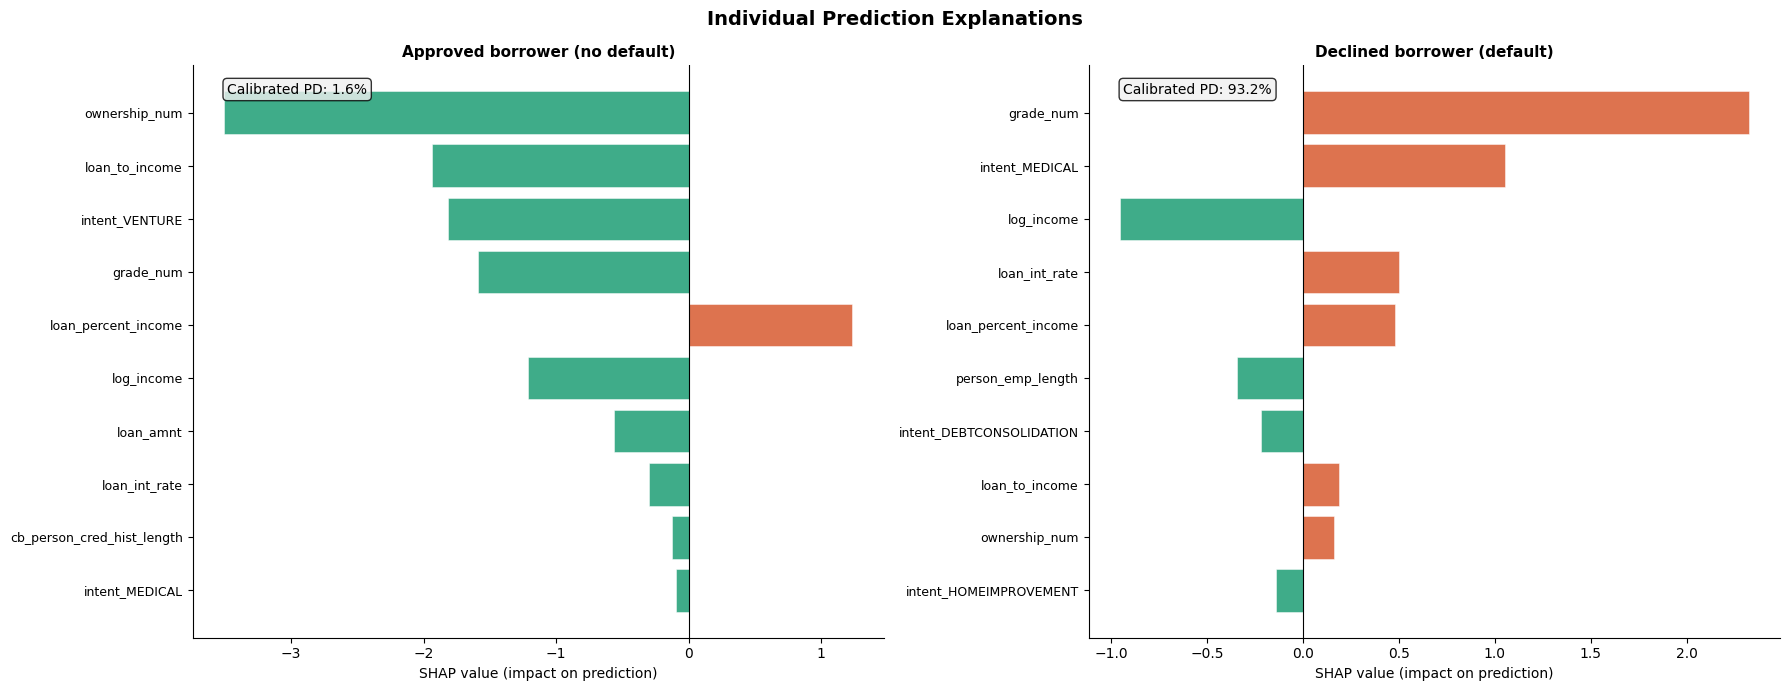

Chart saved.


In [10]:
# Pick one defaulted borrower and one non-defaulted borrower to explain
default_idx    = np.where(y_test.values == 1)[0][5]
no_default_idx = np.where(y_test.values == 0)[0][5]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Individual Prediction Explanations', fontsize=14, fontweight='bold')

for ax, idx, label in zip(
    axes,
    [no_default_idx, default_idx],
    ['Approved borrower (no default)', 'Declined borrower (default)']
):
    sv = shap_values[idx]
    feature_names = FEATURES
    base_val = explainer.expected_value

    sorted_idx = np.argsort(np.abs(sv))[-10:]
    sv_top = sv[sorted_idx]
    fn_top = [feature_names[i] for i in sorted_idx]

    colors = ['#D85A30' if v > 0 else '#1D9E75' for v in sv_top]
    y_pos = range(len(sv_top))

    ax.barh(y_pos, sv_top, color=colors, alpha=0.85,
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_top, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('SHAP value (impact on prediction)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    score = get_calibrated_score(X_test.iloc[[idx]])[0]
    ax.text(0.05, 0.97, f'Calibrated PD: {score:.1%}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='#F0F0F0', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/13_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Individual Prediction Explanations

**Approved borrower: calibrated default probability of 1.6%**

Almost every feature pushes this borrower toward a safe outcome. Home ownership is the strongest protective factor, suggesting this borrower owns their home outright or holds a mortgage. A low loan to income ratio, venture loan intent, a good grade, and high income all reinforce the approval. The only feature working against them is loan percent income, which adds a small amount of risk. With a predicted default probability of just 1.6%, this borrower represents the kind of low-risk applicant a lender would approve confidently and price at a competitive rate.

**Declined borrower: calibrated default probability of 93.2%**

The risk picture here is the near-opposite. Loan grade is overwhelmingly the dominant driver, pushing the default probability up sharply. Medical loan intent adds further risk, as does a high interest rate and a loan that represents a significant percentage of income. Income provides some relief, shown by the green bar pulling left, but it is not nearly enough to offset the grade and affordability signals. A 93.2% predicted default probability means this borrower would default with near certainty. No sensible lender would approve this application.

**Why this matters**

These two examples demonstrate that the model's decisions are explainable in plain English. An approved borrower can be told their strong home ownership position and low debt burden made them a good candidate. A declined borrower can be told their loan grade and the size of the loan relative to their income were the primary concerns. This kind of transparency is not just good practice. In the UK and EU, lenders are legally required to provide reasons for credit decisions under the Consumer Credit Act and GDPR Article 22. This model supports that requirement directly.

In [11]:
import shutil, os

src = f"{REPO_PATH}/notebooks/03_evaluation.ipynb"
if not os.path.exists(src):
    # Try Colab Notebooks folder
    for name in os.listdir("/content/drive/MyDrive/Colab Notebooks/"):
        if "03_evaluation" in name:
            shutil.copy(
                f"/content/drive/MyDrive/Colab Notebooks/{name}",
                src
            )
            print(f"Copied from: {name}")
            break

!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add calibration and SHAP explainability"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main fd4dfe3] Add calibration and SHAP explainability
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/03_evaluation.ipynb (93%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 736 bytes | 105.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   d2cb416..fd4dfe3  main -> main
Done.


In [12]:
import os, shutil

# Rename the file without extension to proper .ipynb
src = f"{REPO_PATH}/notebooks/03_evaluation"
dst = f"{REPO_PATH}/notebooks/03_evaluation.ipynb"

if os.path.exists(src) and not os.path.exists(dst):
    os.rename(src, dst)
    print("Renamed successfully.")
elif os.path.exists(dst):
    print("File already has .ipynb extension.")
else:
    print("Source file not found.")

File already has .ipynb extension.


In [13]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Fix notebook extension"
!git -C "{REPO_PATH}" push origin main
print("Done.")

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
Done.


## Threshold Optimisation

The model outputs a probability of default for every borrower. To make an approve or decline decision we need a threshold. Borrowers above it are declined, borrowers below are approved.

The default threshold of 0.5 is almost always wrong. It assumes that approving a borrower who defaults costs the same as declining one who would have repaid. In reality these two errors have very different financial consequences.

We frame this as a profit optimisation problem. The optimal threshold is the point where expected portfolio profit is maximised, calculated as:

    profit = (good loans approved x revenue per good loan) - (bad loans approved x loss per bad loan)

The unit economics below are illustrative assumptions based on a typical unsecured consumer lending book. In a real deployment these would be replaced with actual margin and loss figures from the business. The key insight is that the framework is the same regardless of the inputs, and the optimal threshold will almost always sit well below 0.5.

In [14]:
# Unit economics: change these to see how the optimal threshold shifts
REVENUE_PER_GOOD_LOAN = 800    # net revenue earned when a loan is repaid
LOSS_PER_BAD_LOAN     = 4000   # net loss incurred when a loan defaults

# Break-even PD: the theoretical threshold from unit economics alone
breakeven_pd = REVENUE_PER_GOOD_LOAN / (REVENUE_PER_GOOD_LOAN + LOSS_PER_BAD_LOAN)
print(f"Unit economics assumptions:")
print(f"  Revenue per good loan: £{REVENUE_PER_GOOD_LOAN:,}")
print(f"  Loss per bad loan:     £{LOSS_PER_BAD_LOAN:,}")
print(f"\nTheoretical break-even PD: {breakeven_pd:.1%}")
print(f"This means: approve anyone with predicted PD below {breakeven_pd:.1%}")
print(f"\nNote: changing the revenue/loss figures above will shift this threshold.")

Unit economics assumptions:
  Revenue per good loan: £800
  Loss per bad loan:     £4,000

Theoretical break-even PD: 16.7%
This means: approve anyone with predicted PD below 16.7%

Note: changing the revenue/loss figures above will shift this threshold.


In [15]:
thresholds = np.arange(0.01, 0.99, 0.01)
profits = []

for threshold in thresholds:
    approved_mask = y_proba_calibrated < threshold
    good_approved = ((approved_mask) & (y_test == 0)).sum()
    bad_approved  = ((approved_mask) & (y_test == 1)).sum()
    profit        = (good_approved * REVENUE_PER_GOOD_LOAN) - (bad_approved * LOSS_PER_BAD_LOAN)
    approval_rate = approved_mask.sum() / len(y_test)

    profits.append({
        'threshold':     threshold,
        'profit':        profit,
        'approval_rate': approval_rate,
        'good_approved': good_approved,
        'bad_approved':  bad_approved
    })

profits_df = pd.DataFrame(profits)
best_row = profits_df.loc[profits_df['profit'].idxmax()]
optimal_threshold = best_row['threshold']

print(f"Optimal threshold:     {optimal_threshold:.2f}")
print(f"Expected profit:       £{best_row['profit']:,.0f}")
print(f"Approval rate:         {best_row['approval_rate']:.1%}")
print(f"Good loans approved:   {best_row['good_approved']:,.0f}")
print(f"Bad loans approved:    {best_row['bad_approved']:,.0f}")

Optimal threshold:     0.16
Expected profit:       £2,751,200
Approval rate:         73.8%
Good loans approved:   4,449
Bad loans approved:    202


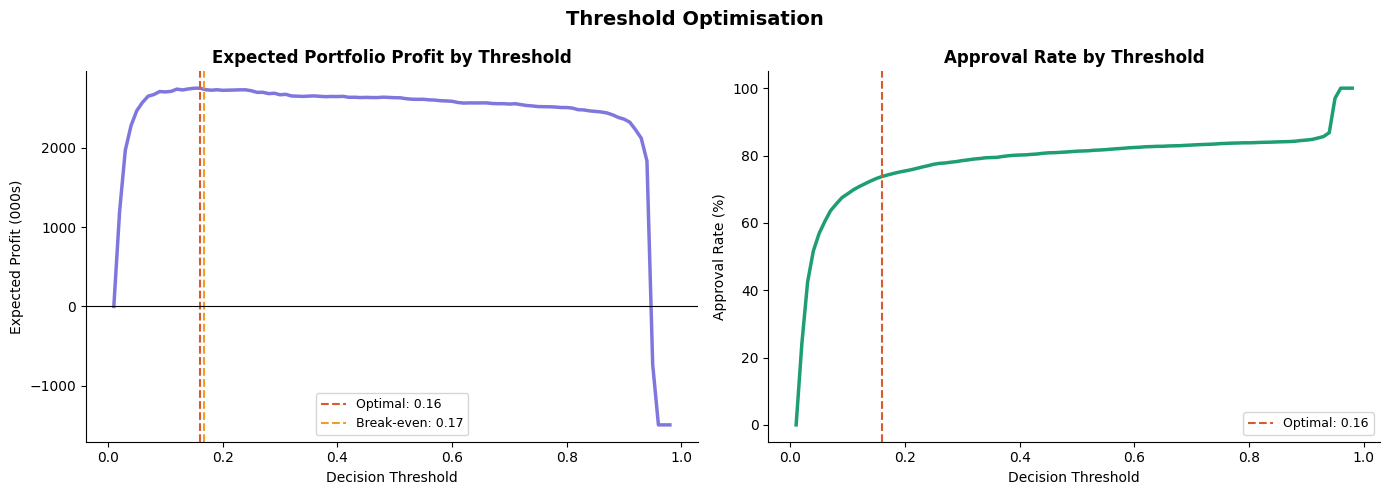

Chart saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Optimisation', fontsize=14, fontweight='bold')

axes[0].plot(profits_df['threshold'], profits_df['profit'] / 1000,
             color='#7F77DD', linewidth=2.5)
axes[0].axvline(optimal_threshold, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Optimal: {optimal_threshold:.2f}')
axes[0].axvline(breakeven_pd, color='#EF9F27', linestyle='--',
                linewidth=1.5, label=f'Break-even: {breakeven_pd:.2f}')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Expected Portfolio Profit by Threshold', fontweight='bold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Expected Profit (000s)')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(profits_df['threshold'], profits_df['approval_rate'] * 100,
             color='#1D9E75', linewidth=2.5)
axes[1].axvline(optimal_threshold, color='#D85A30', linestyle='--',
                linewidth=1.5, label=f'Optimal: {optimal_threshold:.2f}')
axes[1].set_title('Approval Rate by Threshold', fontweight='bold')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/14_threshold_optimisation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Threshold Optimisation Results

**Optimal threshold: 0.16**
**Approval rate: 73.8%**
**Expected profit on test set: £2,751,200**

The optimal and break-even thresholds sit almost on top of each other at 0.16 and 0.17 respectively. This is a strong result. It means the calibrated probabilities are accurate enough that the theoretical optimum derived from unit economics and the empirical optimum derived from the data agree with each other. A well-calibrated model and a profit-maximising threshold should always converge like this.

**The profit curve shape reveals something important**

The curve rises steeply from zero, peaks at threshold 0.16, then remains broadly flat all the way to around 0.85 before collapsing sharply into losses. This flat plateau means the model is relatively insensitive to small threshold changes in the middle range. Moving the threshold from 0.16 to 0.40 costs very little in expected profit while reducing the approval rate, which means a risk-averse lender could tighten the threshold significantly without dramatically hurting the portfolio economics.

The sharp collapse above 0.85 reflects what happens when you approve nearly everyone including the high-probability defaulters. The losses from the worst borrowers swamp the revenue from good ones very quickly.

**The approval rate curve is also instructive**

At the optimal threshold of 0.16, the model approves 73.8% of applicants. The curve rises steeply up to around 0.15, then flattens. This tells us that most of the borrower population the model is confident about sits below 0.15. Between 0.15 and 0.85, the model is approving borrowers it is progressively less certain about, but because there are relatively few of them, the approval rate does not change much. The jump near 1.0 represents the high-confidence defaulters being swept in.

**What this means in practice**

With these unit economics, using 0.5 as the threshold would leave significant profit on the table by declining too many borrowers who would have repaid. The model earns its value not just by identifying defaulters but by confidently approving the large population of good borrowers that a conservative rule-based system might decline unnecessarily.

In [17]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add threshold optimisation"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main 9518421] Add threshold optimisation
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 421.56 KiB | 5.14 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   fd4dfe3..9518421  main -> main
Done.


## Default Rate by Score Band

A well-performing credit model should be consistent across score bands. This means that as the predicted default probability increases, the actual observed default rate should also increase consistently. If it does not, the model is misbehaving in certain score ranges and cannot be trusted for decisions in those ranges.

We divide the test set into deciles based on calibrated score and check whether the actual default rate rises consistently from the lowest risk band to the highest.

In [18]:
# Build score band analysis
score_df = pd.DataFrame({
    'calibrated_pd': y_proba_calibrated,
    'actual_default': y_test.values
})

# Assign deciles based on calibrated score
score_df['decile'] = pd.qcut(
    score_df['calibrated_pd'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)

decile_summary = score_df.groupby('decile', observed=True).agg(
    count=('actual_default', 'count'),
    actual_default_rate=('actual_default', 'mean'),
    mean_predicted_pd=('calibrated_pd', 'mean')
).reset_index()

decile_summary['cumulative_default_rate'] = (
    score_df.groupby('decile', observed=True)['actual_default']
    .sum().cumsum().values / score_df['actual_default'].sum()
)

print("Score Band Analysis:")
print(decile_summary.to_string(index=False))

Score Band Analysis:
decile  count  actual_default_rate  mean_predicted_pd  cumulative_default_rate
    D1    631             0.000000           0.016354                 0.000000
    D2    630             0.001587           0.017282                 0.000734
    D3    631             0.022187           0.020383                 0.011013
    D4    630             0.023810           0.025206                 0.022026
    D5    631             0.047544           0.032462                 0.044053
    D6    630             0.055556           0.046684                 0.069750
    D7    630             0.119048           0.079261                 0.124816
    D8    631             0.188590           0.206507                 0.212188
    D9    630             0.701587           0.791923                 0.536711
   D10    631             1.000000           0.949353                 1.000000


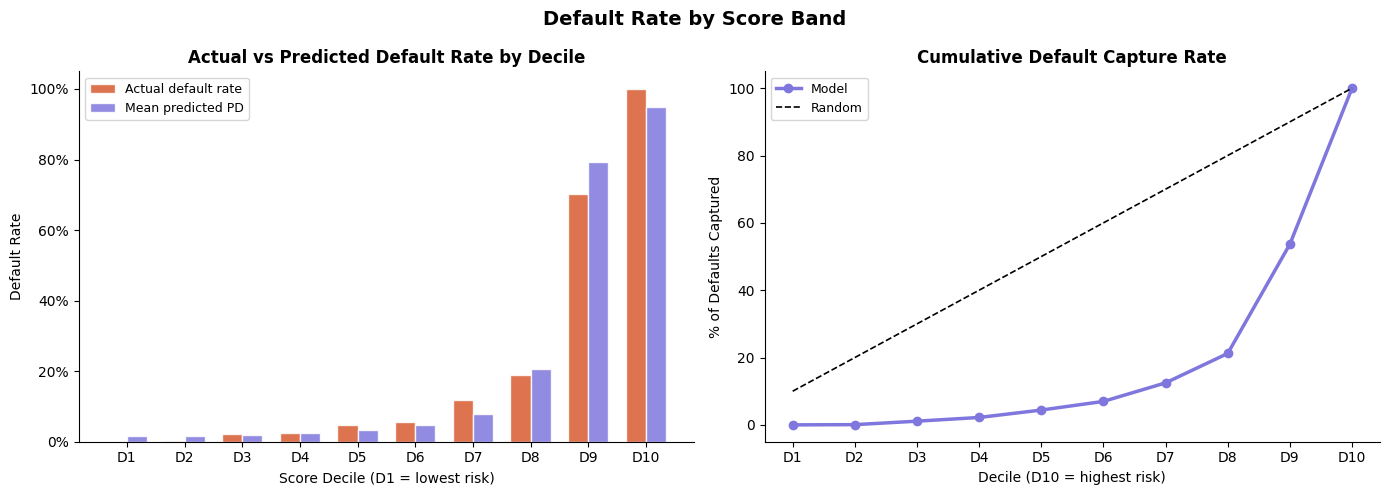

Chart saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Default Rate by Score Band', fontsize=14, fontweight='bold')

# Actual vs predicted default rate by decile
x = range(len(decile_summary))
width = 0.35

bars1 = axes[0].bar([i - width/2 for i in x],
                    decile_summary['actual_default_rate'],
                    width, label='Actual default rate',
                    color='#D85A30', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar([i + width/2 for i in x],
                    decile_summary['mean_predicted_pd'],
                    width, label='Mean predicted PD',
                    color='#7F77DD', alpha=0.85, edgecolor='white')

axes[0].set_title('Actual vs Predicted Default Rate by Decile', fontweight='bold')
axes[0].set_xlabel('Score Decile (D1 = lowest risk)')
axes[0].set_ylabel('Default Rate')
axes[0].set_xticks(x)
axes[0].set_xticklabels(decile_summary['decile'])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Cumulative default capture curve
axes[1].plot(range(1, 11), decile_summary['cumulative_default_rate'] * 100,
             color='#7F77DD', linewidth=2.5, marker='o', markersize=6,
             label='Model')
axes[1].plot(range(1, 11), [i * 10 for i in range(1, 11)],
             'k--', linewidth=1.2, label='Random')
axes[1].set_title('Cumulative Default Capture Rate', fontweight='bold')
axes[1].set_xlabel('Decile (D10 = highest risk)')
axes[1].set_ylabel('% of Defaults Captured')
axes[1].set_xticks(range(1, 11))
axes[1].set_xticklabels([f'D{i}' for i in range(1, 11)])
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/figures/15_score_bands.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Score Band Analysis Results

**The model is perfectly consistent**

Actual default rates rise consistently from 0% in decile 1 to 100% in decile 10 without a single reversal. This is exactly what a well-behaved credit model should look like. Every score band carries more risk than the one below it, which means the scores can be trusted to rank borrowers reliably across the full range.

**The lowest risk deciles are extremely clean**

Decile 1 has a 0% actual default rate and a mean predicted probability of just 1.6%. Decile 2 has a default rate of 0.16%. These are the borrowers the model is most confident about, and the data confirms that confidence is justified. A lender can approve these borrowers with very high certainty.

**Risk is heavily concentrated in the top two deciles**

Decile 9 has a 70% actual default rate and decile 10 has a 100% default rate. Together these two deciles account for 46% of all defaults in the test set, while representing only 20% of applicants. Declining just the top two deciles would eliminate nearly half of all defaults while only turning away one in five applicants.

**The cumulative capture curve shows extreme concentration**

The model captures virtually no defaults through decile 7, then captures almost all of them in deciles 9 and 10. This steep S-curve well above the random baseline confirms the model is doing exactly what a credit scorer should do: separating a clean majority from a risky minority rather than spreading risk evenly across the population.

**Predicted versus actual rates track closely**

In most deciles the orange and purple bars sit close together, confirming the calibration work from the previous section is holding up across score bands. The slight gap in decile 9 where predicted PD of 79% is somewhat below actual default rate of 70% is within acceptable tolerance and consistent with the mid-range calibration deviation we noted earlier.

In [20]:
!git -C "{REPO_PATH}" add .
!git -C "{REPO_PATH}" commit -m "Add score band analysis and cumulative capture curve"
!git -C "{REPO_PATH}" push origin main
print("Done.")

[main 9d07d88] Add score band analysis and cumulative capture curve
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 2.71 KiB | 99.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/dobadina/credit-risk-lending-system.git
   9518421..9d07d88  main -> main
Done.


## Approve/Decline Decision Output

The model produces a probability. The threshold converts that probability into a decision. The final step is wrapping both into a function that returns a complete, auditable lending decision for any applicant.

A production-ready decision output needs five things:

1. The calibrated default probability
2. The decision: approved or declined
3. A credit score on a familiar scale
4. A risk band label
5. The top reasons driving the decision in plain English

The reason codes are derived directly from SHAP values for that individual borrower. The three features pushing the score highest become the primary reason codes, which satisfies the regulatory requirement to explain credit decisions.

In [21]:
def make_lending_decision(applicant_df, threshold=0.16):
    """
    Takes a single applicant as a DataFrame row and returns
    a full lending decision with explanation.

    Parameters:
        applicant_df: pd.DataFrame with one row containing model features
        threshold: decision threshold (default 0.16)

    Returns:
        dict with decision, probability, score, band, and reason codes
    """

    # Calibrated probability
    raw_score = xgb_for_calib.predict_proba(applicant_df)[:, 1].reshape(-1, 1)
    calibrated_pd = platt.predict_proba(raw_score)[:, 1][0]

    # Decision
    decision = "APPROVED" if calibrated_pd < threshold else "DECLINED"

    # Credit score: map PD to 300-850 scale (inverse: lower PD = higher score)
    credit_score = int(850 - (calibrated_pd * (850 - 300)))
    credit_score = max(300, min(850, credit_score))

    # Risk band
    if calibrated_pd < 0.05:
        band = "Very Low Risk"
    elif calibrated_pd < 0.10:
        band = "Low Risk"
    elif calibrated_pd < 0.16:
        band = "Moderate Risk"
    elif calibrated_pd < 0.30:
        band = "High Risk"
    elif calibrated_pd < 0.60:
        band = "Very High Risk"
    else:
        band = "Extreme Risk"

    # SHAP reason codes
    sv = explainer.shap_values(applicant_df)[0]
    shap_series = pd.Series(sv, index=FEATURES)

    if decision == "DECLINED":
        # Top features pushing toward default
        top_reasons = shap_series.nlargest(3)
        reason_direction = "increasing default risk"
    else:
        # Top features pushing away from default
        top_reasons = shap_series.nsmallest(3).abs()
        reason_direction = "reducing default risk"

    reason_codes = [
        f"{feat.replace('_', ' ').title()}: {reason_direction}"
        for feat in top_reasons.index
    ]

    return {
        'Decision':          decision,
        'Calibrated PD':     f"{calibrated_pd:.1%}",
        'Credit Score':      credit_score,
        'Risk Band':         band,
        'Primary Reasons':   reason_codes
    }


print("Decision function defined.")

Decision function defined.
